In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()                # ожидаем pipeline/
REPO_DIR = NB_DIR.parent
APP_DIR = REPO_DIR / "app"
INPUT_DIR = NB_DIR / "input"
TEMPLATES_DIR = NB_DIR / "templates"

# Берём конфиг из app/, чтобы константы (ArUco-dict, размеры, ID) были в одном месте
sys.path.insert(0, str(APP_DIR))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from config import (
    ARUCO_DICT, MARKER_IDS_BASE, BL_TO_CHAR, CHARS,
    CANVAS_H, CANVAS_W, MARKER_PX, MARGIN, CONTENT_PAD, CONTENT_SCALE,
)

known_ids = sorted(set(MARKER_IDS_BASE) | set(BL_TO_CHAR.keys()))
print(f"Repo:         {REPO_DIR}")
print(f"Input dir:    {INPUT_DIR}")
print(f"Templates:    {TEMPLATES_DIR}")
print(f"Canvas:       {CANVAS_W}x{CANVAS_H}  (marker {MARKER_PX}px, margin {MARGIN}px)")
print(f"Known IDs:    {known_ids}")
print(f"Characters:   {list(CHARS.keys())}")

Repo:         c:\Users\Luga\Documents\GitHub\ink-to-motion
Input dir:    c:\Users\Luga\Documents\GitHub\ink-to-motion\pipeline\input
Templates:    c:\Users\Luga\Documents\GitHub\ink-to-motion\pipeline\templates
Canvas:       1754x1240  (marker 80px, margin 60px)
Known IDs:    [0, 1, 2, 3, 4, 5]
Characters:   ['001', '002', '003']


# UI-макет

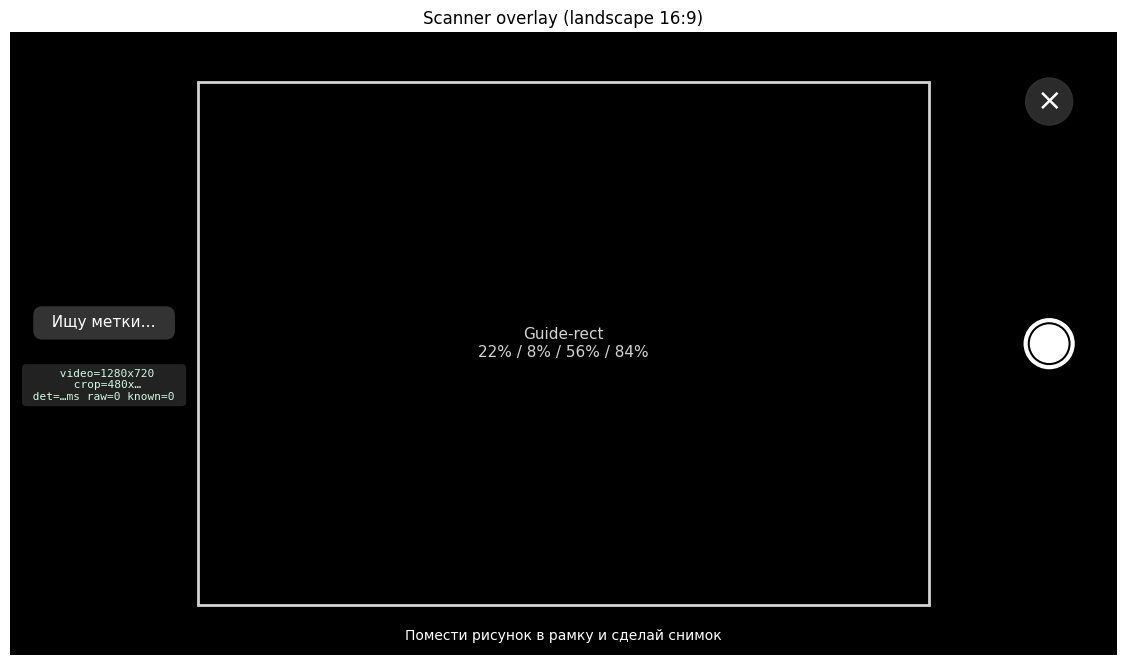

In [10]:
# UI-макет сцены сканера (landscape 16:9) — что видит юзер
STAGE_W, STAGE_H = 1600, 900

fig, ax = plt.subplots(figsize=(12, 6.75))
ax.set_xlim(0, STAGE_W); ax.set_ylim(STAGE_H, 0)   # y-down как в CSS
ax.set_aspect('equal'); ax.axis('off')

# Фон сцены
ax.add_patch(plt.Rectangle((0, 0), STAGE_W, STAGE_H, color='#000'))

# Guide-rect — A4 landscape (ratio 297:210 ≈ 1.414)
gx, gy, gw, gh = 0.17*STAGE_W, 0.08*STAGE_H, 0.66*STAGE_W, 0.84*STAGE_H

ax.add_patch(plt.Rectangle((gx, gy), gw, gh, fill=False,
                           edgecolor='lightgray', linewidth=2))
ax.text(gx + gw/2, gy + gh/2, 'Guide-rect\n22% / 8% / 56% / 84%',
        color='lightgray', ha='center', va='center', fontsize=11)

# Close button — по той же вертикали что и затвор, размер 68×68
close_x = STAGE_W*(1-0.04) - 34    # та же X, что у затвора
close_y = 100                      # сверху
ax.add_patch(plt.Circle((close_x, close_y), 34, color='#333', alpha=0.85))
ax.text(close_x, close_y, '×', color='white', ha='center', va='center', fontsize=22)

# Shutter (top 50% right 4%, 68×68, обводка + белый круг)
sx, sy = STAGE_W*(1-0.04) - 34, STAGE_H*0.5
ax.add_patch(plt.Circle((sx, sy), 34, fill=False, edgecolor='white', linewidth=3))
ax.add_patch(plt.Circle((sx, sy), 27, color='white'))

# Badge «Ищу метки…» — в левой колонке, по центру высоты
left_cx = gx / 2           # середина пустой полосы слева от rect
ax.text(left_cx, STAGE_H/2 - 30, '  Ищу метки…  ',
        color='white', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#333', edgecolor='none'))

# Debug-line — под бэджем, там же слева
ax.text(left_cx, STAGE_H/2 + 60,
        ' video=1280x720\n crop=480x…\n det=…ms raw=0 known=0 ',
        color='#d1fae5', ha='center', va='center', fontsize=8,
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#222', edgecolor='none'))

# Hint (bottom 2%, center)
ax.text(STAGE_W/2, STAGE_H*0.98,
        'Помести рисунок в рамку и сделай снимок',
        color='white', ha='center', va='bottom', fontsize=10)

ax.set_title('Scanner overlay (landscape 16:9)')
plt.tight_layout(); plt.show()


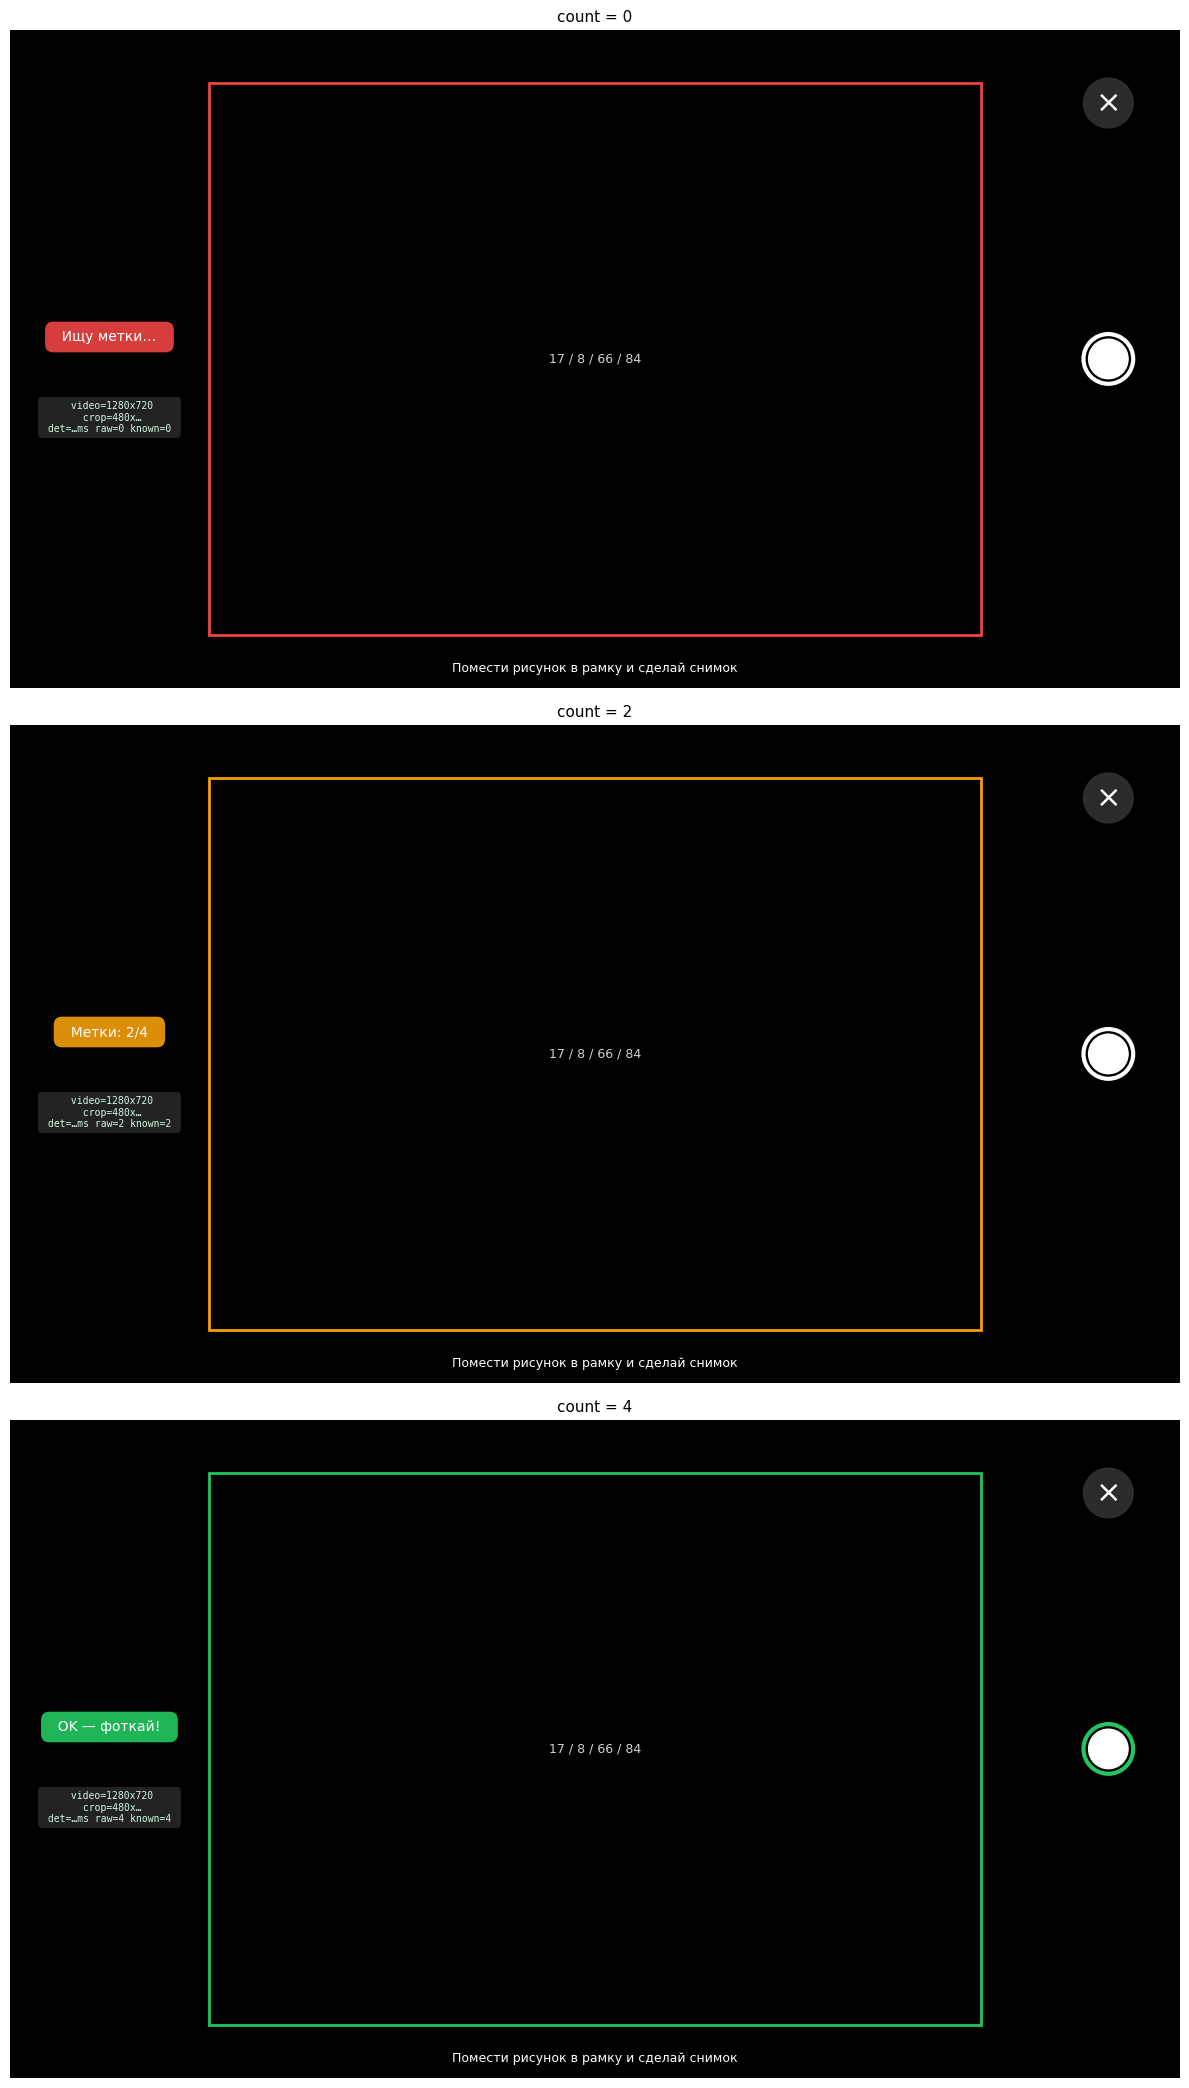

In [13]:
def render_mockup(count=0, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6.75))
    ax.set_xlim(0, STAGE_W); ax.set_ylim(STAGE_H, 0)
    ax.set_aspect('equal'); ax.axis('off')

    # Цвета/тексты по count (логика из camera.js:setFrameColor)
    if count >= 4:
        stroke       = (34/255, 197/255, 94/255)         # зелёный
        badge_bg     = (34/255, 197/255, 94/255, 0.92)
        badge_text   = 'OK — фоткай!'
        shutter_edge = stroke
    elif count >= 1:
        stroke       = (245/255, 158/255, 11/255)        # жёлтый (amber-500)
        badge_bg     = (245/255, 158/255, 11/255, 0.9)
        badge_text   = f'Метки: {count}/4'
        shutter_edge = 'white'
    else:
        stroke       = (239/255, 68/255, 68/255)         # красный
        badge_bg     = (239/255, 68/255, 68/255, 0.9)
        badge_text   = 'Ищу метки…'
        shutter_edge = 'white'


    # Сцена
    ax.add_patch(plt.Rectangle((0, 0), STAGE_W, STAGE_H, color='#000'))

    # Guide-rect — A4 landscape
    gx, gy, gw, gh = 0.17*STAGE_W, 0.08*STAGE_H, 0.66*STAGE_W, 0.84*STAGE_H
    ax.add_patch(plt.Rectangle((gx, gy), gw, gh, fill=False,
                               edgecolor=stroke, linewidth=2))
    ax.text(gx + gw/2, gy + gh/2, '17 / 8 / 66 / 84',
            color='lightgray', ha='center', va='center', fontsize=9)

    # Close (та же X, что у затвора, 68×68)
    close_x, close_y = STAGE_W*(1-0.04) - 34, 100
    ax.add_patch(plt.Circle((close_x, close_y), 34, color='#333', alpha=0.85))
    ax.text(close_x, close_y, '×', color='white',
            ha='center', va='center', fontsize=22)

    # Shutter
    sx, sy = STAGE_W*(1-0.04) - 34, STAGE_H*0.5
    ax.add_patch(plt.Circle((sx, sy), 34, fill=False, edgecolor=shutter_edge, linewidth=3))
    ax.add_patch(plt.Circle((sx, sy), 27, color='white'))

    # Badge (левая колонка)
    left_cx = gx / 2
    ax.text(left_cx, STAGE_H/2 - 30, f'  {badge_text}  ',
            color='white', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.6', facecolor=badge_bg, edgecolor='none'))

    # Debug-line
    ax.text(left_cx, STAGE_H/2 + 80,
            f' video=1280x720\n crop=480x…\n det=…ms raw={count} known={count} ',
            color='#d1fae5', ha='center', va='center', fontsize=7,
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#222', edgecolor='none'))

    # Hint
    ax.text(STAGE_W/2, STAGE_H*0.98,
            'Помести рисунок в рамку и сделай снимок',
            color='white', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'count = {count}', fontsize=11)


fig, axes = plt.subplots(3, 1, figsize=(12, 21))
for ax, c in zip(axes, [0, 2, 4]):
    render_mockup(c, ax)
plt.tight_layout(); plt.show()